# 01 - PyTorch datasets and transforms

PyTorch is an open-source machine learning library developed by Facebook (Meta).

The main data structure in PyTorch is the tensor. A tensor is a generalization of vectors and matrices and is easily extended to higher dimensions. Tensors are similar to NumPy’s ndarrays, with the addition being that Tensors can also be used on a GPU to accelerate computing.

These tutorials are inspired by the book "[Deep Learning with PyTorch](https://pytorch.org/assets/deep-learning/Deep-Learning-with-PyTorch.pdf)" by Stevens et al and can be seen as a summary of the part I of the book regarding PyTorch itself.


## Contents

In this notebook, we will cover the following two topics:

### 1. The CIFAR Dataset 

The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. We will use the CIFAR-10 dataset to demonstrate how to load a dataset in PyTorch. We will also show how to plot images and count the number of samples for each class.

You will learn how to:

1. Load the CIFAR dataset in Pytorch.
2. Getting started with the CIFAR dataset.
3. Plot images.
4. Count how many samples there are for each class.

Of course, one can also create custom datasets in PyTorch but we will not cover this in this notebook.

### 2. Transforms

Data transformations are common in machine learning. They are used to preprocess and augment the data. PyTorch provides a module called `torchvision` to work with image data. The `torchvision` module provides a number of functions that can be used to transform the data.

Typical examples include converting the data to a PyTorch tensor, normalizing the data, and various data augmentation techniques such as random cropping, rotations, and flips.

You will learn how to:

1. Convert an image into a PyTorch-friendly object (a tensor). 
2. Include the preprocessing step (transform operator) when loading the dataset.
3. Normalize the dataset using the mean and standard deviation of the dataset.



We start by importing the necessary libraries.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import random_split

For reproducibility, we set the seed for the random number generators of PyTorch and NumPy.

In [3]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

## 1. The CIFAR Dataset

From [Deep Learning with PyTorch](https://pytorch.org/assets/deep-learning/Deep-Learning-with-PyTorch.pdf):

> CIFAR-10 consists of 60,000 tiny 32 × 32 color (RGB) images, labeled with an integer corresponding to 1 of 10 classes: airplane (0), automobile (1), bird (2), cat (3), deer (4), dog (5), frog (6), horse (7), ship (8), and truck (9). Nowadays, CIFAR-10 is considered too simple for developing or validating new research, but it serves our learning purposes just fine.

CIFAR is one of the datasets available in PyTorch (see [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html#torchvision-datasets)):

> All datasets are subclasses of [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) [...] Hence, they can all be passed to a [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) which can load multiple samples parallelly

These might make things even more confusing first but we will see in this notebook that manipulating PyTorch datasets is actually really simple

### 1.1 Loading the CIFAR dataset in Pytorch

In [4]:
# Where to find the data or where to download the data if not found
data_path = "data"

# Instantiates a dataset for the training (and validation) and downloads the data if it is not present
cifar10_train_val = datasets.CIFAR10(
    data_path,       # location from which the data will be downloaded
    train=True,      # whether we’re interested in the training set or the test set
    download=True,   # whether we allow PyTorch to download the data if not found in 'data_path'
    )

# Same with test dataset
cifar10_test = datasets.CIFAR10(data_path, train=False, download=True) 

100.0%
/home/henrik/school/inf265/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


As with NumPy, we have the `.shape` attribute to check the shape of the data. We see that the test set contains 10,000 images of 32x32 pixels and 3 channels (RGB).

In [5]:
print(f"Test data shape: {cifar10_test.data.shape}")

Test data shape: (10000, 32, 32, 3)


#### Splitting our training dataset into training/validation datasets

In machine learning we usually split our dataset into 3 datasets:
- Training data: to train the model(s).
- Validation data: to select the best model (and hyper-parameters).
- Test data: to estimate the performance of the selected model on unseen data (DO NOT touch this data until you have a fixed model and hyperparameters).

The CIFAR-10 dataset in PyTorch is already split into training and test sets. So we only need to split the training set `cifar10_train_val` into training and validation sets. To do so, we can use [torch.utils.data.random_split()](https://pytorch.org/docs/stable/data.html?highlight=random_split#torch.utils.data.random_split).

In [7]:
val_size = 0.1 # Use 10% of the training data for validation

# Compute the number of samples we want the training and validation set
n_train_val = len(cifar10_train_val) # Total number of samples in the training and validation set (50000)
n_train = int(n_train_val * (1 - val_size)) # Number of training samples (45000)
n_val = n_train_val - n_train # Number of validation samples (5000)


# Split the datasets and give a seed so that we all get the same split
# [n_train, n_val]: specifies the sizes of the subsets we want to create.
# Use a random number generator to ensure that the code is reproducible
rng = torch.Generator().manual_seed(seed)
cifar10_train, cifar10_val = random_split(cifar10_train_val, lengths=[n_train, n_val], generator=rng)

print(f"Number of training samples: {len(cifar10_train)}")
print(f"Number of validation samples: {len(cifar10_val)}")
print(f"Number of test samples: {len(cifar10_test)}")

Number of training samples: 45000
Number of validation samples: 5000
Number of test samples: 10000


### 1.2 Getting started with the CIFAR dataset

From now on we will try to answer the following questions:

1. How to access elements of this dataset? 
1. What do these elements look like in python?
1. How to plot images?
1. How to manipulate them in order to feed our neural network with them? 

In [8]:
# Let us index the 100th element of the training dataset
idx = 99
x = cifar10_train[idx]

print(f"Type of x: {type(x)}")
print(f"Length of x: {len(x)}")
print(f"Type of x[0]: {type(x[0])}")
print(f"Type of x[1]: {type(x[1])}")

Type of x: <class 'tuple'>
Length of x: 2
Type of x[0]: <class 'PIL.Image.Image'>
Type of x[1]: <class 'int'>


Looks like each sample consists of a pair `(image, label)` where `image` is a PIL (Pillow) image and `label` is an integer representing the class label. Let us inspect each of these elements further.

We can convert the label to a string using the `classes` attribute of the dataset. We can also plot the image using the `matplotlib` library.

Image shape: (32, 32)
Label: 1 (automobile)


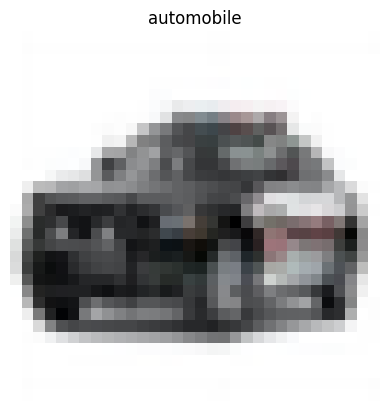

Image array shape: (32, 32, 3)
Image array type: uint8


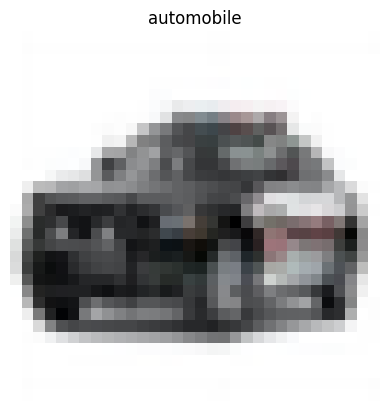

In [9]:
img, label = x # Unpack the tuple

# Print image size
print(f"Image shape: {img.size}")

# Print label and class name
class_name = cifar10_train.dataset.classes[label]
print(f"Label: {label} ({class_name})")

# Plot the image with matplotlib as a PIL image
plt.imshow(img)
plt.title(class_name)
plt.axis('off')
plt.show()

# Convert to a NumPy array
img_array = np.array(img)
print(f"Image array shape: {img_array.shape}")
print(f"Image array type: {img_array.dtype}")

# Plot the image with matplotlib as a NumPy array
plt.imshow(img_array)
plt.title(class_name)
plt.axis('off')
plt.show()

#### Plotting more images

Let us plot the first 20 images of the training set.

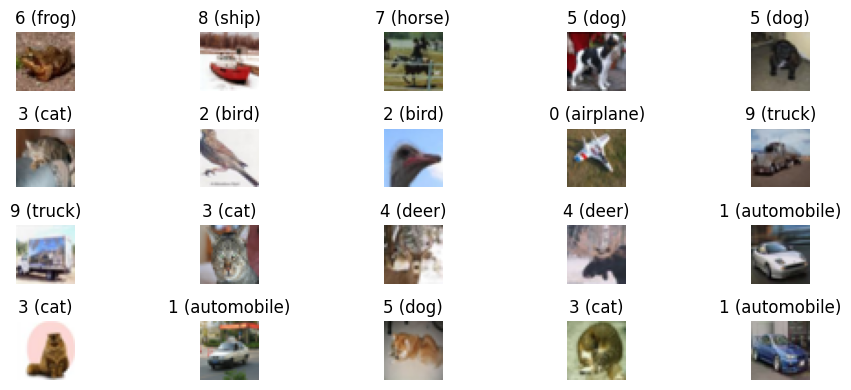

In [10]:
# Create a grid of images with 4 rows and 5 columns
fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axs.flat):
    img, label = cifar10_train[i]
    class_name = cifar10_train.dataset.classes[label]
    ax.imshow(img)
    ax.set_title(f"{label} ({class_name})")
    ax.axis('off')

fig.tight_layout()
plt.show()

#### Count samples for each class

In real life, datasets are not perfect and some problems could come from an imbalanced dataset. That is to say a dataset with an unequal distribution of classes. To check that the dataset does not contain 10 times as many cats as dogs, we can simply count how many samples we have for each class. To do that we can use [collections.Counter()](https://docs.python.org/3/library/collections.html#collections.Counter)

6 (frog) has 4498 samples
8 (ship) has 4502 samples
7 (horse) has 4494 samples
5 (dog) has 4493 samples
3 (cat) has 4496 samples
2 (bird) has 4506 samples
0 (airplane) has 4518 samples
9 (truck) has 4533 samples
4 (deer) has 4468 samples
1 (automobile) has 4492 samples


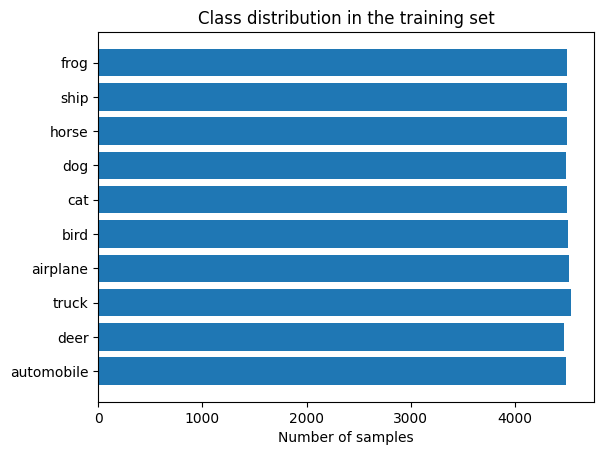

In [11]:
# Create a list of all the labels in the training set and use a Counter to count the number of samples for each class
labels_train = [label for _, label in cifar10_train]
counter = Counter(labels_train)

# Print the number of samples for each class
for label, count in counter.items():
    class_name = cifar10_train.dataset.classes[label]
    print(f"{label} ({class_name}) has {count} samples")

# Bar plot visualizing the class distribution
fig, ax = plt.subplots()
labels, counts = zip(*counter.items())
class_names = [cifar10_train.dataset.classes[label] for label in labels]
y_pos = np.arange(len(class_names))
ax.barh(y_pos, counts)
ax.set_yticks(y_pos)
ax.set_yticklabels(class_names)
ax.invert_yaxis()
ax.set_xlabel('Number of samples')
ax.set_title('Class distribution in the training set')
plt.show()


The training dataset looks very balanced with around 4500 samples for each class.

## 2. Data Transformations

[Tensors](https://pytorch.org/docs/stable/tensors.html#torch.Tensor) are the main data structure in PyTorch. They are similar to NumPy arrays but can also be used on a GPU to accelerate computing. They can also hold other information such as the gradient of the tensor (used for backpropagation), but we will look at this later.

If you know how to work with NumPy arrays, you will find it easy to work with PyTorch tensors. Note that instead of `axis`, PyTorch uses `dim` to refer to dimensions. PyTorch comes with a lot of functions to manipulate tensors, similar to NumPy. Examples include [torch.sum()](https://pytorch.org/docs/stable/generated/torch.sum.html), [torch.argmax()](https://pytorch.org/docs/stable/generated/torch.argmax.html), [torch.sort()](https://pytorch.org/docs/stable/generated/torch.sort.html), [torch.abs()](https://pytorch.org/docs/stable/generated/torch.abs.html), [torch.cos()](https://pytorch.org/docs/stable/generated/torch.cos.html), and many more.

When working with neural networks, the first dimension of the input (or any intermediate tensor) usually represents the batch size. For images, a batch of 2-dimensional arrays with multiple channels (e.g. RGB) is represented as a 4-dimensional tensor. The dimensions are usually ordered as `(batch_size, channels, height, width)`, or `(B, C, H, W)` for short.



### 2.1 From PIL images and NumPy arrays to PyTorch tensors

We will now use the `torchvision.transforms` module to convert the images to PyTorch tensors.

The `transforms.ToTensor()` function converts a PIL image (or a NumPy array) to a tensor and rescales the pixel values to the range [0, 1]. Note that the shape of the tensor is `(C, H, W)` instead of the usual `(H, W, C)` shape of NumPy arrays. This is because PyTorch uses channels first instead of channels last.

That is, the transformation consists of two steps:

1. Reshape a ``(H, W, C)`` image into a ``(C, H, W)`` tensor (Height, Width, Channel (color))
2. Rescale ``[0 255]`` int arrays into ``[0 1]`` float tensors



First, we convert from a NumPy array to a tensor.

In [12]:
x, label = cifar10_train[0] # Get the first image and label in the training set

x_numpy = np.array(x) # Convert the image to a NumPy array

# Print the shape of the NumPy array
print(f"Image shape (NumPy array): {x_numpy.shape}")

to_tensor = transforms.ToTensor() # Create a function to convert a NumPy array to a PyTorch tensor
x_tensor = to_tensor(x_numpy) # Convert the NumPy array to a PyTorch tensor

# Print the shape of the PyTorch tensor (note that the order of the dimensions has changed from H x W x C to C x H x W)
print(f"Image shape (PyTorch tensor): {x_tensor.shape}")

# Print the RGB values of the first pixel (note the range has been scaled to [0, 1])
print(f"First pixel RGB values (NumPy): {x_numpy[0,0]}")
print(f"First pixel RGB values (PyTorch): {x_tensor[:, 0, 0]}")

Image shape (NumPy array): (32, 32, 3)
Image shape (PyTorch tensor): torch.Size([3, 32, 32])
First pixel RGB values (NumPy): [139 117 101]
First pixel RGB values (PyTorch): tensor([0.5451, 0.4588, 0.3961])


We can also directly convert a PIL image to a tensor with the `transforms.ToTensor()` transformation.

In [13]:
print(f"Type of img: {type(img)}")
transformed_img = to_tensor(img) # Apply the transformation to the image
print(f"Type of transformed_img: {type(transformed_img)}")
print(f"Shape of transformed_img: {transformed_img.shape}")

Type of img: <class 'PIL.Image.Image'>
Type of transformed_img: <class 'torch.Tensor'>
Shape of transformed_img: torch.Size([3, 32, 32])


#### Ploting images as tensors

We can also plot the images as tensors. We need to use the `permute()` method to change the order of the dimensions from `(C, H, W)` to `(H, W, C)`.

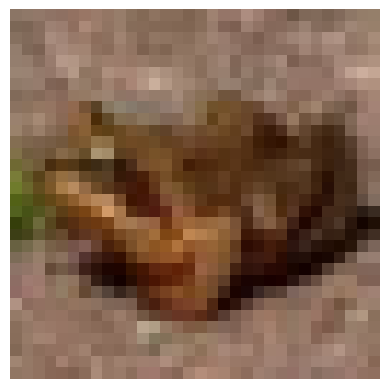

In [16]:
# plt.imshow(x_tensor)   #Does not work because the shape has changed!
plt.imshow(x_tensor.permute(1, 2, 0))  # This works :) 
plt.axis('off')
plt.show()

The [`Tensor.permute()`](https://pytorch.org/docs/stable/tensors.html#torch.Tensor.permute) method is used to change the order of the dimensions of a tensor. It takes the desired order of the dimensions as arguments. For example, `permute(2, 0, 1)` changes the order of the dimensions from `(C, H, W)` to `(H, W, C)`.

### 2.2 Include the transforms when loading the dataset

We can directly convert the images into tensors when loading a dataset from [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html#torchvision-datasets) as they all have a ``transform`` parameter.

Note that if you later create your own dataset class, you can also include the transformation in the dataset class itself.

Let us load the CIFAR-10 dataset again, but this time we will include the transformation `transforms.ToTensor()` when loading the dataset so that the dataset yields tensors instead of PIL images.

In [17]:
tensor_cifar10_train_val = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor())
print(type(tensor_cifar10_train_val[0][0]))

<class 'torch.Tensor'>


/home/henrik/school/inf265/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### 2.3 Normalizing the dataset

In machine learning we almost always do some preprocessing such as normalizing (or standardizing) the dataset. 

The [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html#torchvision-transforms) module can easily performs the most common image transformations such as [resize](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.Resize), [normalize](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.Normalize), etc. 

In addition, this module allows us to quickly define pipelines of basic preprocessing functions using the [transforms.Compose](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.Compose) method. The `transforms.Compose` method takes a list of transformations and composes them into a single transformation!

The `transforms.Normalize()` function normalizes (actually standardizes) the tensor with a given mean and standard deviation. The formula for standardization is:

$$
\text{standardized value} = \frac{\text{value} - \text{mean}}{\text{std}}
$$

The standardization is usually done separately for each channel. The mean and standard deviation are calculated from the training set (we don't want to leak information from the test set).

In [18]:
images_train_val = cifar10_train_val.data / 255.0 # Convert the pixel values to the range [0, 1]
mean_rgb = np.mean(images_train_val, axis=(0, 1, 2)) # Compute the mean of each channel
std_rgb = np.std(images_train_val, axis=(0, 1, 2)) # Compute the standard deviation of each channel

print(f"Mean values for each channel: {mean_rgb}")
print(f"Standard deviation for each channel: {std_rgb}")

Mean values for each channel: [0.49139968 0.48215841 0.44653091]
Standard deviation for each channel: [0.24703223 0.24348513 0.26158784]


We now use the computed mean and standard deviation to create normalized datasets. Note that you can use different transforms for the training and test sets. For example, you might want to use data augmentation techniques such as random cropping, rotations, and flips for the training set but not for the test set.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9892129..2.0945773].


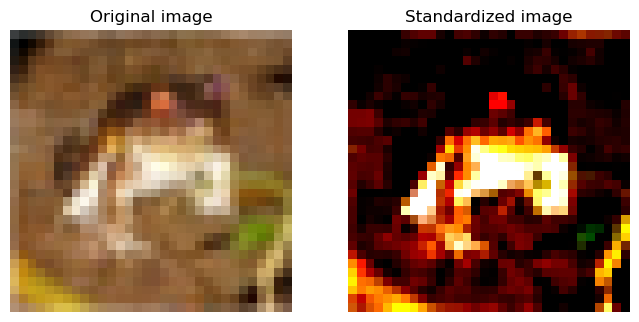

In [30]:
# Define a transformation that converts the images to PyTorch tensors and normalizes the pixel values based on the computed mean and standard deviation
tranform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb)
])

# Create the transformed training and validation datasets
transformed_cifar10_train_val = datasets.CIFAR10(data_path, train=True, download=False, transform=tranform)
transformed_cifar10_test = datasets.CIFAR10(data_path, train=False, download=False, transform=tranform)

# Plot the first image in the transformed training set side-by-side with the original image and show colorbars
img, label = cifar10_train_val[0]
transformed_img, _ = transformed_cifar10_train_val[0]

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(img)
axs[0].set_title('Original image')
axs[0].axis('off')
cax = axs[1].imshow(transformed_img.permute(1, 2, 0))
axs[1].set_title('Standardized image')
axs[1].axis('off')
plt.show()


The normalized/standardized image looks a bit funny. For us humans, it is easier to see the original image, but for the neural network, the standardized samples usually give better results.